In [96]:
import torch
from pathlib import Path
import preprocess_data as ppd
from process_session import session as ps
import process_probe as pp
import numpy as np
from preprocess_data import *
import models as models
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score
import pandas as pd
import sys
import os
from process_attribution import *
from plots import *
import optuna # Import Optuna
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
import importlib
import IntegratedGradient

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
df = pd.read_csv('units_info.csv')
print(df.head())

      unit_id  session_id                                       genotype  \
0  1179685687  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
1  1179685618  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
2  1179685304  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
3  1179685455  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   
4  1179684888  1047969464  Sst-IRES-Cre/wt;Ai32(RCL-ChR2(H134R)_EYFP)/wt   

   optotagged  cluster_id  pyr  sst  vip  coupling_index  normalized_depth  \
0           0           0    1    0    0             NaN               NaN   
1           0           0    1    0    0             NaN               NaN   
2           0           0    1    0    0             NaN               NaN   
3           0           4    0    0    0        0.206024          0.527778   
4           0           0    0    0    0             NaN               NaN   

   ...  burstIndex_Royer2012  burstIndex_Mizuseki2012  num_conn_e_to_e  \


In [2]:
# Session obj contains stimulus, channel, and unit information
output_dir  = r'Y:\buzsakilab\Buzsakilabspace\LabShare\NoamNitzan\Open_Access\Allen_2022'
session_id  = 1044385384
session_obj = ps(session_id, df, output_dir)

# hyperparameters
input_size = len(session_obj.units)
hidden_size = 50 # 
num_layers = 1
num_epochs = 15 # 
bands = [(0.5, 4), (4, 8), (8, 12), (12, 25), (25, 50), (50, 100), (100, 200), (200, 400)]
criterion  = torch.nn.MSELoss()
batch_size = 32

In [3]:
# Spikes obj contains Spike matrix
bin_size=0.004
spikes_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=bin_size, sigma=3)
spikes_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[1])
# spikes_obj.convolve_with_gaussian() # skip convolution
spikes_obj.minmax()

# Probe obj contains LFP data
# Getting LFP  for active trials
lfp_obj = ppd.pre_process_lfp(session_id, session_obj.channels, session_obj.active_times[0],
                              session_obj.active_times[1], output_dir) 
lfp_obj.filter_lfp(take_power = True)
lfp_obj.downsample_lfp(5) # Downsample by 5
lfp_obj.align_lfp(spikes_obj.spkMat.shape[0])
num_channels = len(lfp_obj.channels)

100%|██████████| 8/8 [03:12<00:00, 24.02s/it]


In [4]:
chani = 5 # deep layer
bandi = 0 # broadband

# X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
#                                                       seqlength, prediction_lag=0, test_size=0.2, random_state=42)

# train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size , device)

In [5]:
def objective(trial):
    """Optuna objective function to minimize validation loss."""

    # --- Suggest Hyperparameters ---
    embedding_dim = trial.suggest_categorical("embedding_dim", [32, 64, 128, 256])
    num_layers = trial.suggest_int("num_layers", 1, 6)
    seqlength = trial.suggest_categorical("seqlength", np.arange(25, 500, 25).tolist())
    

    # Ensure num_heads is a divisor of embedding_dim
    possible_heads = [h for h in [1, 2, 4, 8, 16] if embedding_dim % h == 0]
    if not possible_heads: # Fallback if no divisors found (shouldn't happen with choices above)
         possible_heads = [1]
    num_heads = trial.suggest_categorical("num_heads", possible_heads)

    dropout = trial.suggest_float("dropout", 0.05, 0.5, step=0.05)
    lr = trial.suggest_float("lr", 1e-5, 1e-2, log=True)
    weight_decay = trial.suggest_float("weight_decay", 1e-6, 1e-2, log=True)

    # --- Instantiate Model ---
    model = models.SpikingTransformer(
        input_size=input_size, # Use global num_neurons
        seqlength=seqlength,    # Use global seqlength
        embedding_dim=embedding_dim,
        num_heads=num_heads,
        num_layers=num_layers,
        dropout=dropout
    ).to(device)

    criterion = torch.nn.MSELoss()
    
    # --- Train and Evaluate ---
    processor = models.process_model(model, criterion, device)

    # Use val_dataloader as the 'test_dataloader' for evaluation within train
    # Train for a fixed number of epochs for hyperparameter comparison
    # You might need more epochs in final training
    num_optuna_epochs = 10 # Adjust as needed - balance speed and convergence
    
    X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                      seqlength, prediction_lag=0, test_size=0.2, random_state=42)

    train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size , device)

    transformer_train_loss, transformer_test_loss = processor.train(train_dataloader,
                                        test_dataloader , num_optuna_epochs, lr=lr, weight_decay=weight_decay)

    # --- Return the metric to minimize (e.g., final validation loss) ---
    final_val_loss = transformer_test_loss[-1]

    # --- Optional: Optuna Pruning (Stop unpromising trials early) ---
    trial.report(final_val_loss, step=num_optuna_epochs - 1)
    if trial.should_prune():
        raise optuna.exceptions.TrialPruned()

    return final_val_loss # Optuna minimizes this value

In [6]:
output_dir = Path(output_dir)
output_dir_models = output_dir / 'models' / str(session_id)

study_name = "spiking-transformer-optimization-fixed-bs" # Updated name
storage_name = output_dir_models / f"{study_name}.db"

study = optuna.create_study(
    direction="minimize",
    load_if_exists=True,
    pruner=optuna.pruners.MedianPruner()
)

print(f"Sampler is {study.sampler.__class__.__name__}")
study.optimize(objective, n_trials=20)


[I 2025-05-13 11:41:53,157] A new study created in memory with name: no-name-39992335-e15d-443f-acb8-b1abd331229f


Sampler is TPESampler


[I 2025-05-13 11:42:20,151] Trial 0 finished with value: 0.9021572004193845 and parameters: {'embedding_dim': 64, 'num_layers': 4, 'seqlength': 250, 'num_heads': 1, 'dropout': 0.15000000000000002, 'lr': 0.003859771305758329, 'weight_decay': 4.972182005023251e-05}. Best is trial 0 with value: 0.9021572004193845.
[I 2025-05-13 11:43:00,402] Trial 1 finished with value: 0.6770289937655131 and parameters: {'embedding_dim': 64, 'num_layers': 3, 'seqlength': 275, 'num_heads': 16, 'dropout': 0.25, 'lr': 0.0023801271832957533, 'weight_decay': 0.00010887692680860521}. Best is trial 1 with value: 0.6770289937655131.
[I 2025-05-13 11:43:49,727] Trial 2 finished with value: 0.6767389894577495 and parameters: {'embedding_dim': 64, 'num_layers': 6, 'seqlength': 100, 'num_heads': 8, 'dropout': 0.35000000000000003, 'lr': 5.876200260840643e-05, 'weight_decay': 8.667380850265388e-05}. Best is trial 2 with value: 0.6767389894577495.
[I 2025-05-13 11:44:28,342] Trial 3 finished with value: 0.3059635709608

In [ ]:
# Print the best hyperparameters 
best_params   = study.best_params
best_accuracy = study.best_value
print("Best Hyperparameters: ", best_params)
print("Best Acc: ", best_accuracy)

Best Hyperparameters:  {'embedding_dim': 32, 'num_layers': 2, 'seqlength': 50, 'num_heads': 2, 'dropout': 0.1, 'lr': 0.00040429934834439863, 'weight_decay': 6.689911550230387e-06}
Best Acc:  0.3059635709608551


In [5]:
embedding_dim = 32
num_layers = 2
seqlength = 50 
num_heads = 2
dropout = 0.1
lr = 0.0004
weight_decay = 6.7e-06

In [6]:
num_epochs_transformer = 10
transformer_model = models.process_model(models.SpikingTransformer(input_size=input_size, seqlength=seqlength,
                                                                   embedding_dim = embedding_dim,
                                                                   num_heads = num_heads, 
                                                                   num_layers = num_layers,
                                                                   dropout=dropout), criterion, device)

X_train, X_test, y_train, y_test  = chunk_and_reshape(spikes_obj.spkMat, lfp_obj.lfpMat[:,chani,bandi], 
                                                    seqlength, prediction_lag=0, test_size=0.2, random_state=42)

train_dataloader, test_dataloader = get_data_loaders(X_train, X_test, y_train, y_test, batch_size , device)


transformer_train_loss, transformer_test_loss = transformer_model.train(train_dataloader,
                                        test_dataloader , num_epochs_transformer,
                                        lr = lr, weight_decay=weight_decay)

print(f'transformer  train loss: {transformer_train_loss[-1]:.4f}')
print(f'transformer  test loss:  {transformer_test_loss[-1]:.4f}')

transformer  train loss: 0.3026
transformer  test loss:  0.3317


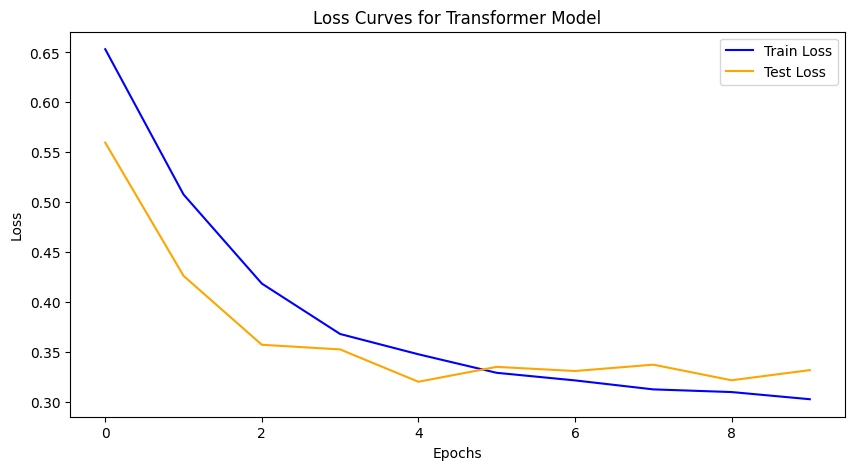

In [7]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(transformer_train_loss, label='Train Loss', color='blue')
ax.plot(transformer_test_loss, label='Test Loss', color='orange')
ax.set_xlabel('Epochs')
ax.set_ylabel('Loss')
ax.set_title('Loss Curves for Transformer Model')
ax.legend()
plt.show()


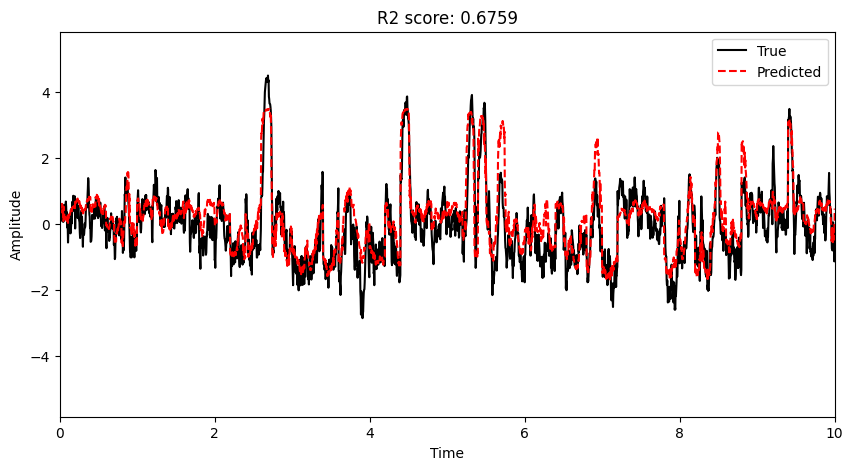

In [8]:
test_spikes = torch.cat([X for X, _ in test_dataloader], dim=0)
test_lfp = torch.cat([y for _, y in test_dataloader], dim=0)

# reshape to time X features
test_spikes = test_spikes.reshape(test_spikes.shape[0] * test_spikes.shape[1], test_spikes.shape[2])
test_lfp = test_lfp.reshape(test_lfp.shape[0] * test_lfp.shape[1])

time = np.linspace(0, test_lfp.shape[0] * bin_size , test_lfp.shape[0])

y_hat_test = transformer_model.evaluate(test_spikes)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(time, test_lfp.cpu().numpy(), 'k', label='True')
ax.plot(time, y_hat_test.cpu().numpy(), '--r', label='Predicted')
ax.set_xlim([0, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
ax.set_title(f'R2 score: {r2_score(test_lfp.cpu().numpy(), y_hat_test.cpu().numpy()):.4f}')
ax.legend()
plt.show()



In [ ]:
attr_dur = 720
X_attr = torch.tensor(spikes_obj.spkMat[:int(attr_dur/bin_size),:]).float().to(device)
num_trials = int(int(attr_dur/bin_size)/seqlength)

ig = IntegratedGradient(transformer_model.model.train().to(device), method='last time point', seqlength=seqlength) 
attrs = ig.run(X_attr, baselines = 0, n_steps = 50)

100%|██████████| 3600/3600 [17:57<00:00,  3.34it/s]


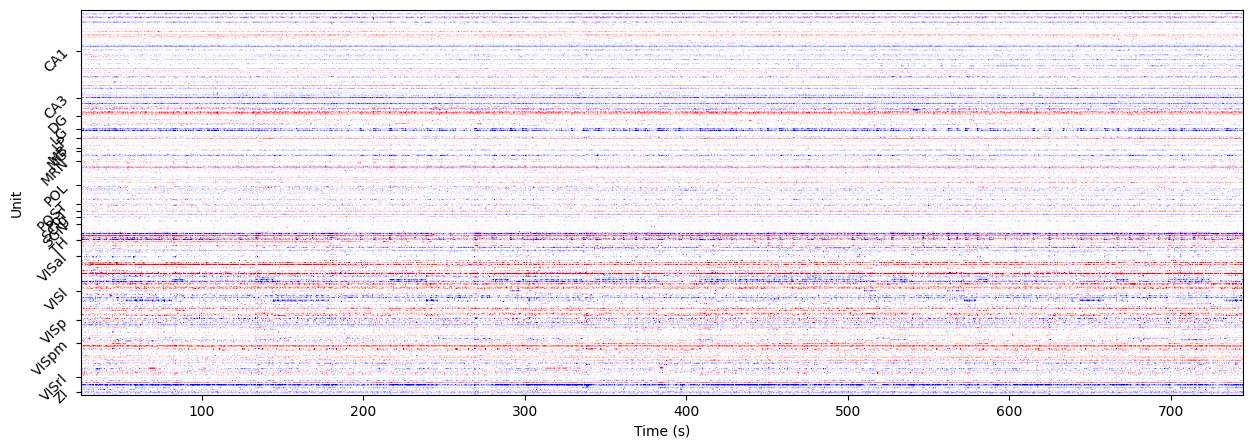

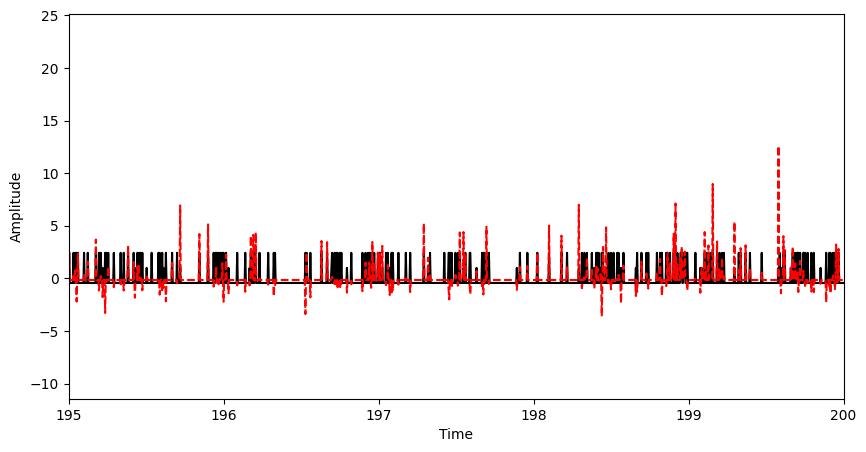

In [ ]:
import importlib
import plots
importlib.reload(plots)
from plots import * 

normalized_attrs = attrs.cpu().numpy() / X_attr.cpu().numpy()
normalized_attrs[np.isnan(normalized_attrs)] = 0
plot_attr_matrix(normalized_attrs, spikes_obj.timestamps[:int(attr_dur/bin_size)], 
                 session_obj, [spikes_obj.timestamps[0], spikes_obj.timestamps[0] + attr_dur])

win = [170, 175]
neuron = 259     

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(spikes_obj.timestamps[:int(attr_dur/bin_size)], 
           zscore(spikes_obj.spkMat[:int(attr_dur/bin_size),neuron]), 'k', label='firing rate')
ax.plot(spikes_obj.timestamps[:int(attr_dur/bin_size)],
              zscore(attrs[:,neuron].cpu().numpy()), '--r', label='attribution score')
ax.set_xlim([spikes_obj.timestamps[0]+win[0], spikes_obj.timestamps[0]+win[1]])
# ax.set_ylim([-10, 10])
ax.set_xlabel('Time')
ax.set_ylabel('Amplitude')
plt.show()

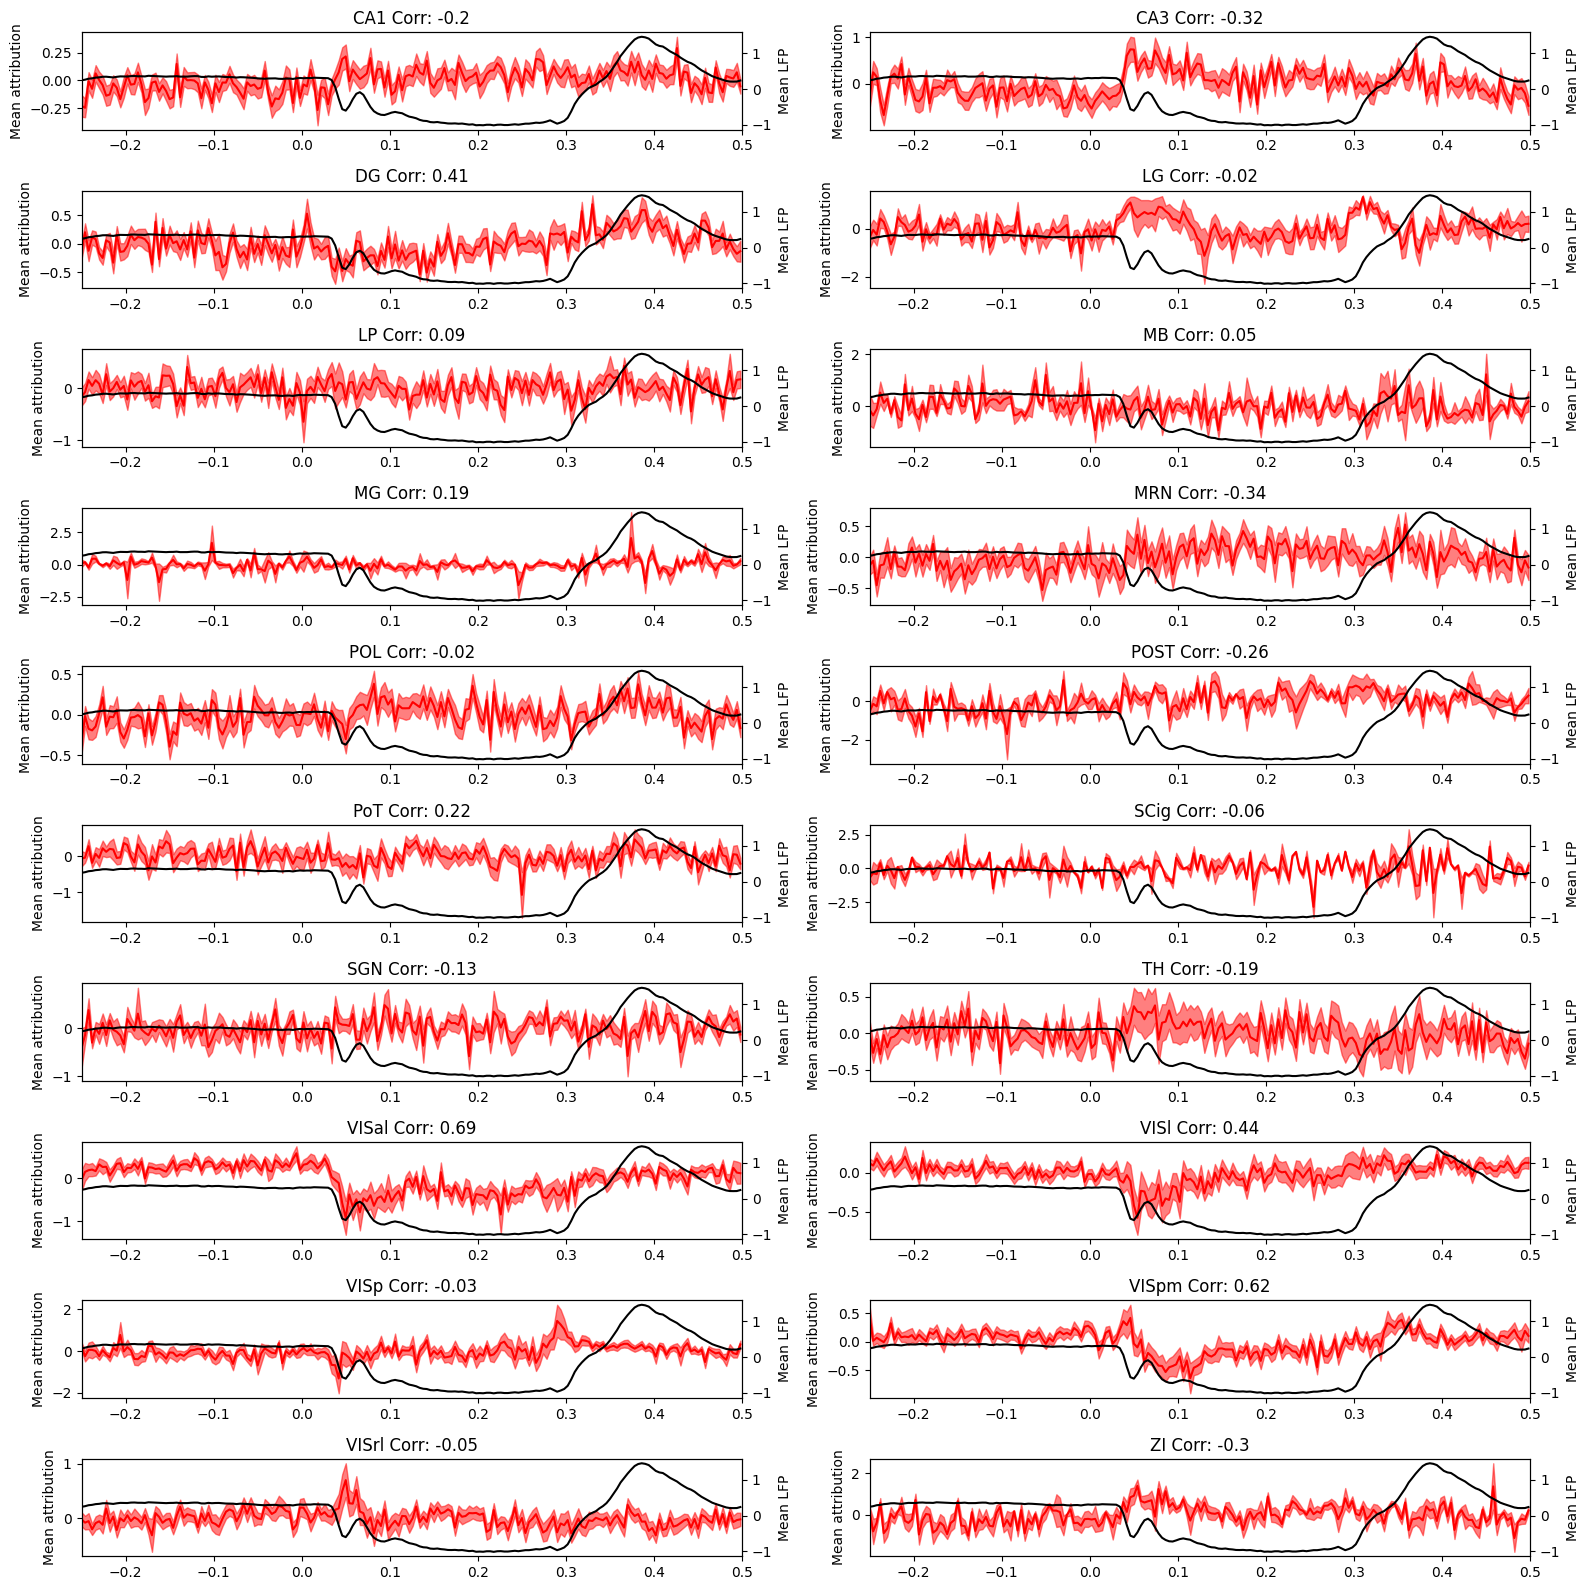

In [16]:
# plot_unit_attr_fr_corr(unit_attr_fr_corr, session_obj, bands)
attr_snippets, lfp_snippets, t = plot_peri_stim_attr(attrs.cpu().numpy() , lfp_obj.lfpMat[:int(attr_dur/bin_size),5,0], session_obj,
                    spikes_obj.timestamps[:int(attr_dur/bin_size)], [-.25, 0.5])

In [72]:
mean_attr = np.mean(normalized_attrs, axis=0)
print(np.argmax(mean_attr, axis=0), session_obj.units.structure_acronym.iloc[np.argmax(mean_attr, axis=0)])
print(np.argmin(mean_attr, axis=0), session_obj.units.structure_acronym.iloc[np.argmin(mean_attr, axis=0)])

# create a dataframe for the attribution scores and the areas
attr_df = pd.DataFrame.from_dict({
    'structure_acronym': session_obj.units.structure_acronym,
    'attribution_score': mean_attr
})

print(attr_df.head())

# group by structure and get the mean absolute attribution score
attr_df['attribution_score'] = np.abs(attr_df['attribution_score'])
attr_df.groupby('structure_acronym').mean().sort_values(by='attribution_score', ascending=False)

259 VISl
586 VISrl
           structure_acronym  attribution_score
id                                             
1049374910             VISpm      -2.007536e-03
1049374988             VISpm       9.923875e-07
1049373561               POL      -8.065181e-03
1049373556               POL       3.414240e-03
1049373138               PoT       1.301108e-02


,attribution_score
structure_acronym,
LG,0.009665
TH,0.007397
ZI,0.004924
VISl,0.004339
VISrl,0.004247
CA3,0.004089
MRN,0.003956
VISal,0.003619
DG,0.003413


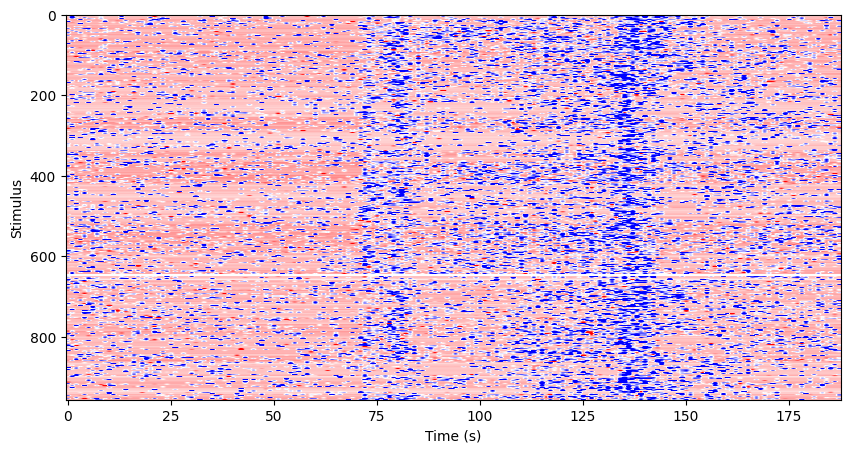

In [95]:
from scipy.stats import zscore
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# ax.imshow(zscore(np.mean(attr_snippets, axis=0).T, axis=1), aspect='auto', cmap='bwr', vmin=-1, vmax=1)
ax.imshow(zscore(attr_snippets[:,:,586 ], axis=1), aspect='auto', cmap='bwr', vmin=-1, vmax=1)

ax.set_xlabel('Time (s)')
ax.set_ylabel('Stimulus')
plt.show()

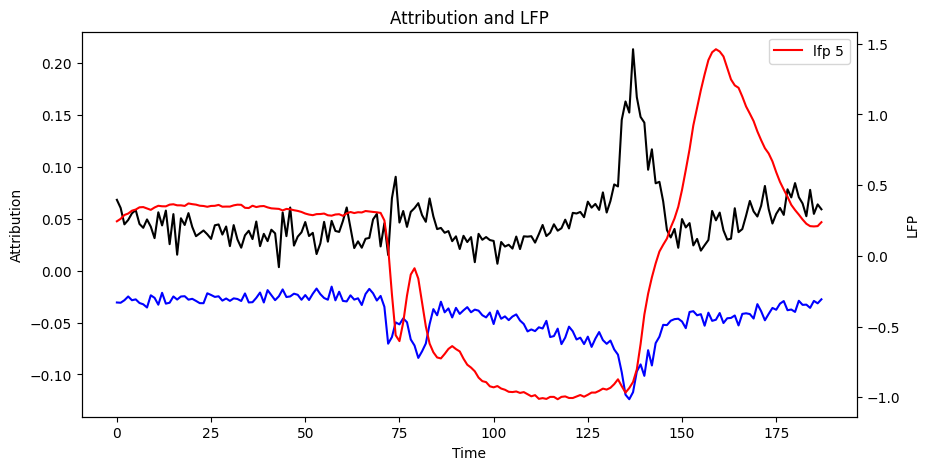

In [37]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.plot(np.mean(attr_snippets[:,:,586], axis=0),'b', label='unit 586')
ax.plot(np.mean(attr_snippets[:,:,259], axis=0),'k', label='unit 259')
ax2 = ax.twinx()
ax2.plot(np.mean(lfp_snippets, axis=0), 'r', label='lfp 5')
ax.set_xlabel('Time')
ax.set_ylabel('Attribution')
ax2.set_ylabel('LFP')
ax.set_title('Attribution and LFP')
plt.legend()
plt.show()

100%|██████████| 623/623 [00:00<00:00, 1639.44it/s]


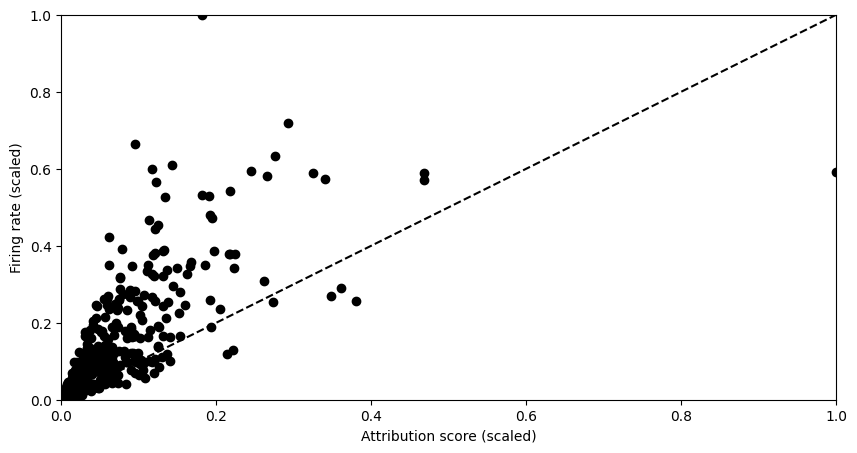

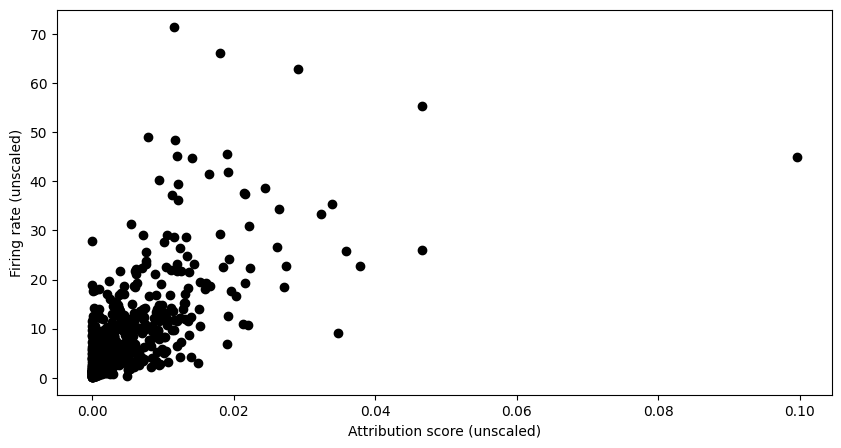

In [ ]:
tmp_obj = ppd.pre_process_spikes(session_obj.units, session_obj.spike_times, bin_size=1)
tmp_obj.getSpkMat(session_obj.active_times[0], session_obj.active_times[0] + attr_dur)

fr2 = np.mean(tmp_obj.spkMat, axis=0) / attr_dur # firing rate in Hz
fr2[fr2 == 0] = 1e-10 # avoid log(0)

# import minmax scaling function
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(scaler.fit_transform(np.mean(np.abs(attrs.cpu().numpy()), axis=0).reshape(-1,1)) , scaler.fit_transform(fr2.reshape(-1,1)), 'ok')
ax.plot([-1,1], [-1, 1], '--k')
ax.set_xlim([0,1])
ax.set_ylim([0,1])
ax.set_xlabel('Attribution score (scaled)')
ax.set_ylabel('Firing rate (scaled)')
plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(np.mean(np.abs(attrs.cpu().numpy()), axis=0), session_obj.units['firing_rate'], 'ok')
# ax.plot([-1,1], [-1, 1], '--k')
# ax.set_xlim([0,1])
# ax.set_ylim([0,1])
ax.set_xlabel('Attribution score (unscaled)')
ax.set_ylabel('Firing rate (unscaled)')
plt.show()

In [105]:
tmp_df = df.copy()
# change the column name 'unit_id' to 'id' and set the index to 'id'
tmp_df.rename(columns={'unit_id': 'id'}, inplace=True)
tmp_df.set_index('id', inplace=True)
# merge session_obj.units with tmp_df on 'id'
merged_df = pd.merge(session_obj.units, tmp_df, left_on='id', right_index=True)
print(merged_df.columns)

Index(['PT_ratio', 'amplitude', 'amplitude_cutoff', 'cluster_id_x',
       'cumulative_drift', 'd_prime', 'firing_rate', 'isi_violations',
       'isolation_distance', 'l_ratio', 'local_index', 'max_drift',
       'nn_hit_rate', 'nn_miss_rate', 'peak_channel_id', 'presence_ratio',
       'quality', 'recovery_slope', 'repolarization_slope', 'silhouette_score',
       'snr', 'spread', 'velocity_above', 'velocity_below',
       'waveform_duration', 'anterior_posterior_ccf_coordinate',
       'dorsal_ventral_ccf_coordinate', 'filtering',
       'left_right_ccf_coordinate', 'probe_channel_number',
       'probe_horizontal_position', 'probe_id', 'probe_vertical_position',
       'structure_acronym', 'session_id', 'genotype', 'optotagged',
       'cluster_id_y', 'pyr', 'sst', 'vip', 'coupling_index',
       'normalized_depth', 'cv2', 'acg_tau_rise', 'acg_tau_decay', 'acg_c',
       'acg_d', 'firingRateISI', 'thetaModulationIndex',
       'burstIndex_Royer2012', 'burstIndex_Mizuseki2012', 'num

In [139]:
keep = np.mean(np.abs(attrs.cpu().numpy()), axis=0) > 0.005

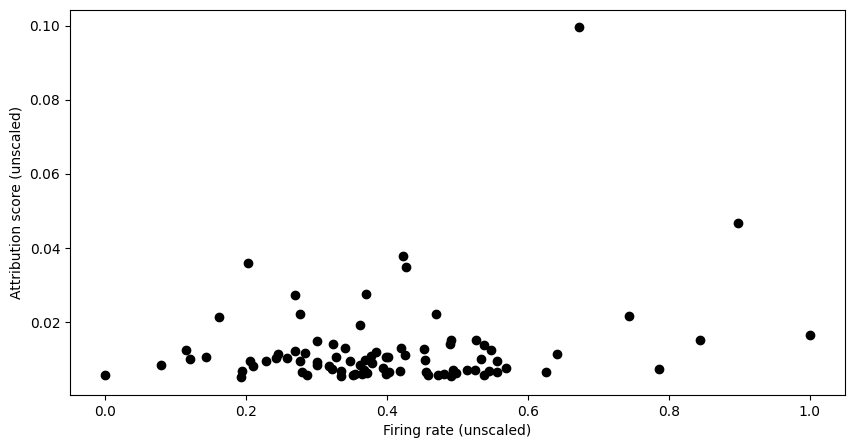

In [143]:
# fig, ax = plt.subplots(1, 1, figsize=(10, 5))
# ax.plot(scaler.fit_transform(merged_df['cv2'].values.reshape(-1,1)), 
#         scaler.fit_transform(np.mean(np.abs(attrs.cpu().numpy()), axis=0).reshape(-1,1)), 'ok')
# ax.plot([-1,1], [-1, 1], '--k')
# ax.set_xlim([0,1])
# ax.set_ylim([0,1])
# ax.set_ylabel('Attribution score (scaled)')
# ax.set_xlabel('Firing rate (scaled)')
# plt.show()

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.plot(merged_df['coupling_index'][keep], np.mean(np.abs(attrs.cpu().numpy()), axis=0)[keep], 'ok')
# ax.plot([-1,1], [-1, 1], '--k')
# ax.set_xlim([0,1])
# ax.set_ylim([0,1])
ax.set_ylabel('Attribution score (unscaled)')
ax.set_xlabel('Firing rate (unscaled)')
plt.show()

In [16]:
# linear regression model 
linear_model = models.LinearRegressionModel(input_size)
ln_train_loss, ln_test_loss = linear_model.train(train_dataloader,
                                               test_dataloader, numepochs=1)

print(f'Linear regression train loss: {ln_train_loss[-1]:.4f}')
print(f'Linear regression test loss: {ln_test_loss[-1]:.4f}')

Linear regression train loss: 0.4509
Linear regression test loss: 3.3875


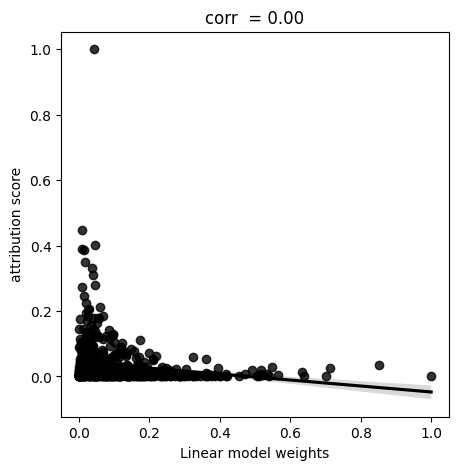

In [24]:
# correlation between linear regression weights and transformer attribution scores
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()

weights = linear_model.model.coef_
mean_attr_transformer = np.mean(attrs.cpu().numpy(), axis=0)

fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.regplot(x=scaler.fit_transform(np.abs(weights).reshape(-1, 1)), 
            y=scaler.fit_transform(np.abs(mean_attr_transformer).reshape(-1, 1)), ax=ax, color='k')
ax.set_xlabel('Linear model weights')
ax.set_ylabel('attribution score')
ax.set_title(f'corr  = {np.corrcoef(weights, mean_attr_transformer)[0,1]:.2f}')
# ax.set_xlim([0, 0.2])
plt.show()

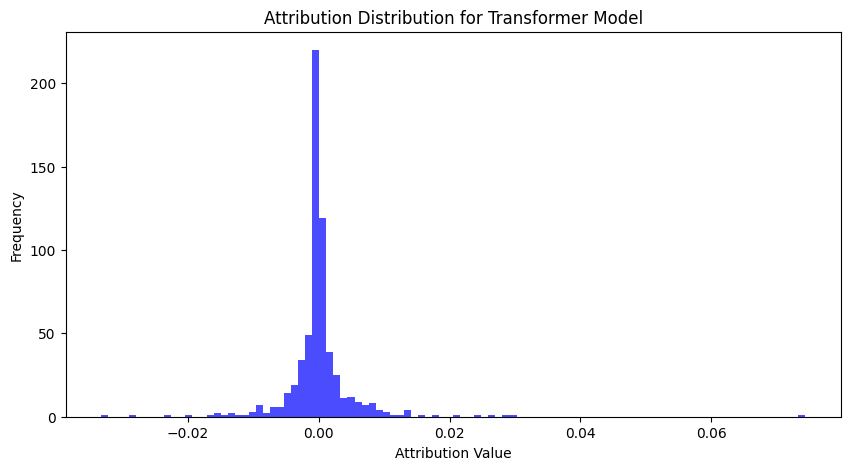

In [20]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(mean_attr_transformer, bins=100, color='blue', alpha=0.7)
ax.set_xlabel('Attribution Value')
ax.set_ylabel('Frequency')
ax.set_title('Attribution Distribution for Transformer Model')
plt.show()


In [26]:
gru_model = models.process_model(models.GRUnet(input_size, hidden_size, num_layers, seqlength=study.best_params['seqlength'], batchNorm=False), criterion, device)
gru_train_loss, gru_test_loss = gru_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'GRU  train loss: {gru_train_loss[-1]:.4f}')
print(f'GRU  test loss: {gru_test_loss[-1]:.4f}')

GRU  train loss: 0.2901
GRU  test loss: 0.3106


In [27]:
ig2 = IntegratedGradient(gru_model.model.train().to(device), method='last time point', seqlength=study.best_params['seqlength']) 
attrs2 = ig2.run(X_attr, baselines = 0, n_steps = 50)

100%|██████████| 3600/3600 [07:18<00:00,  8.21it/s]


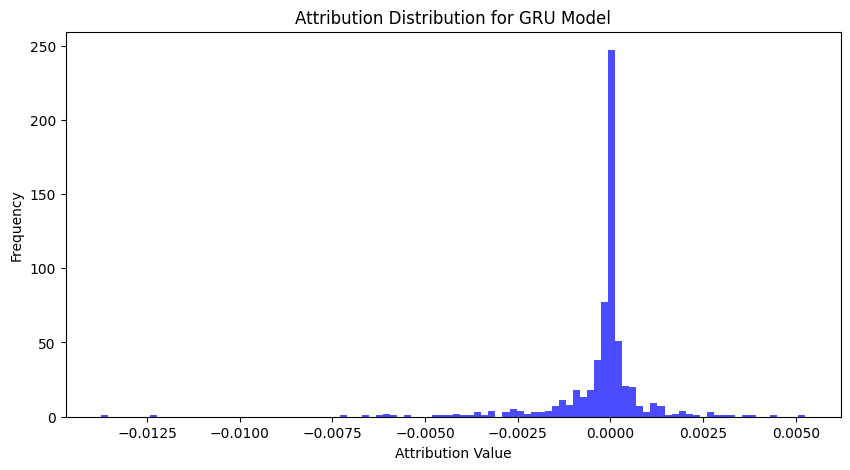

In [28]:
mean_attr_gru = np.mean(attrs2.cpu().numpy(), axis=0)

fig, ax = plt.subplots(1, 1, figsize=(10, 5))
ax.hist(mean_attr_gru, bins=100, color='blue', alpha=0.7)
ax.set_xlabel('Attribution Value')
ax.set_ylabel('Frequency')
ax.set_title('Attribution Distribution for GRU Model')
plt.show()

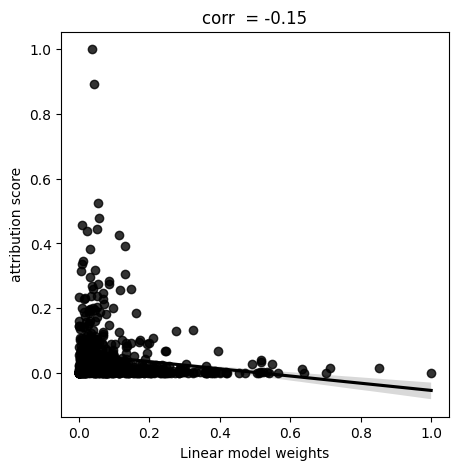

In [49]:
fig, ax = plt.subplots(1, 1, figsize=(5, 5))
sns.regplot(x=scaler.fit_transform(np.abs(weights).reshape(-1, 1)), 
            y=scaler.fit_transform(np.abs(mean_attr_gru).reshape(-1, 1)), ax=ax, color='k')
ax.set_xlabel('Linear model weights')
ax.set_ylabel('attribution score')
ax.set_title(f'corr  = {np.corrcoef(  scaler.fit_transform(np.abs(weights).reshape(-1, 1)).T, scaler.fit_transform(np.abs(mean_attr_gru).reshape(-1, 1)).T )[0,1]:.2f}')
# ax.set_xlim([0, 0.2])
plt.show()

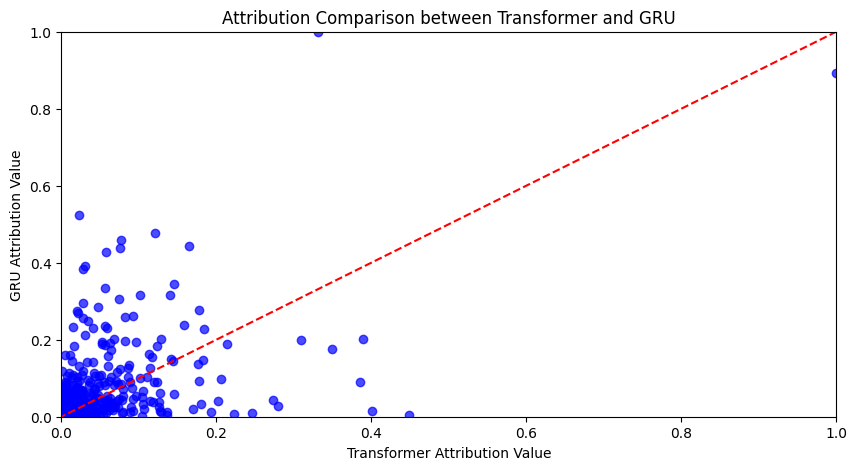

In [50]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.scatter(scaler.fit_transform(np.abs(mean_attr_transformer).reshape(-1, 1)),
           scaler.fit_transform(np.abs(mean_attr_gru).reshape(-1, 1)), color='blue', alpha=0.7)
ax.set_xlabel('Transformer Attribution Value')
ax.set_ylabel('GRU Attribution Value')
ax.set_title('Attribution Comparison between Transformer and GRU')
ax.plot([-1, 1], [-1, 1], 'r--') # Diagonal line for reference
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()

In [ ]:
lstm_model = models.process_model(models.LSTMnet(input_size, hidden_size, num_layers,seqlength, batchNorm=False), criterion, device)
lstm_train_loss, lstm_test_loss = lstm_model.train(train_dataloader,
                                        test_dataloader , num_epochs)

print(f'LSTM  train loss: {lstm_train_loss[-1]:.4f}')
print(f'LSTM  test loss: {lstm_test_loss[-1]:.4f}')

LSTM  train loss: 0.2767
LSTM  test loss: 0.3002


In [98]:
ig3 = IntegratedGradient(lstm_model.model.train().to(device), method='last time point', seqlength=seqlength)
attrs3 = ig3.run(X_attr, baselines = 0, n_steps = 50)
mean_attr_lstm = np.mean(attrs3.cpu().numpy(), axis=0)

100%|██████████| 3600/3600 [09:26<00:00,  6.36it/s]


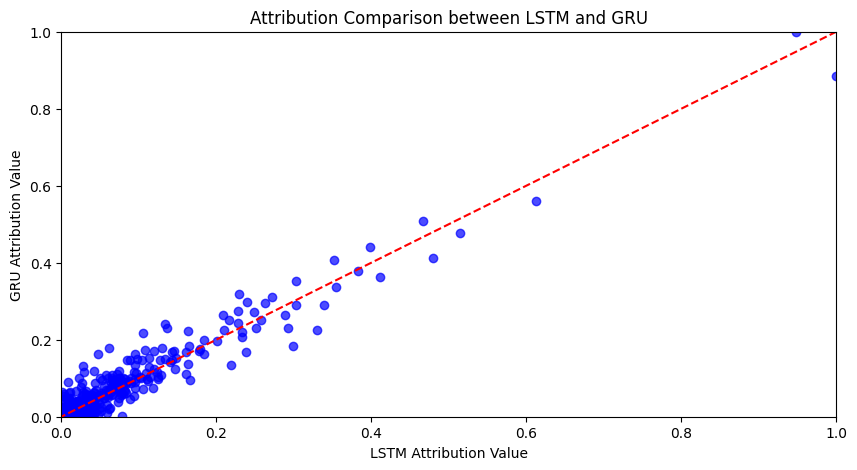

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(10, 5))

ax.scatter(scaler.fit_transform(np.abs(mean_attr_lstm).reshape(-1, 1)),
           scaler.fit_transform(np.abs(mean_attr_gru).reshape(-1, 1)), color='blue', alpha=0.7)
ax.set_xlabel('LSTM Attribution Value')
ax.set_ylabel('GRU Attribution Value')
ax.set_title('Attribution Comparison between LSTM and GRU')
ax.plot([-1, 1], [-1, 1], 'r--') # Diagonal line for reference
plt.xlim([0, 1])
plt.ylim([0, 1])
plt.show()